In [98]:
import fastf1
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer


In [99]:
import os
import fastf1

os.makedirs("f1_cache", exist_ok=True)

In [100]:
fastf1.Cache.enable_cache("f1_cache")

# load the f1 dataset (Qutar , 2024)
session_2024= fastf1.get_session(2024,24,"R")
session_2024.load()
laps_2024=session_2024.laps[['Driver','LapTime','Sector1Time','Sector2Time','Sector3Time']].copy()
laps_2024.dropna(inplace=True)

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


In [101]:
laps_2024.head()

,Driver,LapTime,Sector1Time,Sector2Time,Sector3Time
1,VER,0 days 00:01:54.938000,0 days 00:00:18.209000,0 days 00:00:54.569000,0 days 00:00:42.160000
2,VER,0 days 00:01:38.051000,0 days 00:00:23.196000,0 days 00:00:41.997000,0 days 00:00:32.858000
3,VER,0 days 00:01:29.504000,0 days 00:00:18.166000,0 days 00:00:38.187000,0 days 00:00:33.151000
4,VER,0 days 00:01:29.813000,0 days 00:00:18.056000,0 days 00:00:37.945000,0 days 00:00:33.812000
5,VER,0 days 00:01:29.412000,0 days 00:00:18.012000,0 days 00:00:38.101000,0 days 00:00:33.299000


In [102]:
laps_2024.shape

(1014, 5)

In [103]:
laps_2024['Driver'].value_counts()

Driver
VER    57
GAS    57
ALO    57
LEC    57
HUL    57
HAM    57
PIA    57
RUS    57
SAI    57
NOR    57
MAG    56
STR    56
ZHO    56
ALB    56
TSU    56
DOO    56
LAW    54
BOT    29
COL    25
Name: count, dtype: int64

In [104]:
laps_2024["Driver"].unique()

array(['VER', 'GAS', 'ALO', 'LEC', 'STR', 'MAG', 'TSU', 'ALB', 'ZHO',
       'HUL', 'LAW', 'NOR', 'COL', 'HAM', 'SAI', 'DOO', 'RUS', 'BOT',
       'PIA'], dtype=object)

In [105]:
# convert lap and sector times to seconds
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    laps_2024[f"{col} (s)"] = laps_2024[col].dt.total_seconds()

In [106]:
# aggregate sector times by driver
sector_times_2024 = laps_2024.groupby("Driver").agg({
    "Sector1Time (s)": "mean",
    "Sector2Time (s)": "mean",
    "Sector3Time (s)": "mean"
}).reset_index()
sector_times_2024["TotalSectorTime (s)"] = (
    sector_times_2024["Sector1Time (s)"] +
    sector_times_2024["Sector2Time (s)"] +
    sector_times_2024["Sector3Time (s)"]
)


In [107]:
# clean air race pace from racepace.py
clean_air_race_pace = {
    "VER": 93.191067, "HAM": 94.020622, "LEC": 93.418667, "NOR": 93.428600, "ALO": 94.784333,
    "PIA": 93.232111, "RUS": 93.833378, "SAI": 94.497444, "STR": 95.318250, "HUL": 95.345455,
    "OCO": 95.682128
}

# quali data from Abu Dhabi GP
qualifying_2025 = pd.DataFrame({
    "Driver": ["RUS", "VER", "PIA", "NOR", "HAM", "LEC", "ALO", "HUL", "ALB", "SAI", "STR", "OCO", "GAS"],
    "QualifyingTime (s)": [
        82.645,  # RUS
        82.207,  # VER
        82.437,  # PIA
        82.408,  # NOR
        83.394,  # HAM
        82.730,  # LEC
        82.902,  # ALO
        83.450,  # HUL
        83.416,  # ALB
        83.042,  # SAI
        83.097,  # STR
        82.913,  # OCO
        83.468   # GAS
    ]
})

#average lap times for 2025 season of drivers
average_2025 = {
    "VER": 88.0, "PIA": 89.1, "LEC": 89.2, "RUS": 89.3, "HAM": 89.4, 
    "GAS": 89.5, "ALO": 89.6, "TSU": 89.7, "SAI": 89.8, "HUL": 89.9, 
    "OCO": 90.0, "STR": 90.1, "NOR": 90.2
}

# wet driver performance from the script
driver_wet_performance = {
    "VER": 0.975196, "HAM": 0.976464, "LEC": 0.975862, "NOR": 0.978179, "ALO": 0.972655,
    "RUS": 0.968678, "SAI": 0.978754, "TSU": 0.996338, "OCO": 0.981810, "GAS": 0.978832, "STR": 0.979857
}
qualifying_2025["WetPerformanceFactor"] = qualifying_2025["Driver"].map(driver_wet_performance)



In [108]:
qualifying_2025["CleanAirRacePace (s)"] = qualifying_2025["Driver"].map(clean_air_race_pace)

In [109]:
API_KEY = "57370f03b84e1f8ba3ca648fdeaff96a"
lat, lon = 24.4672, 54.6031  
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()

In [110]:
print(weather_data)

{'cod': '200', 'message': 0, 'cnt': 40, 'list': [{'dt': 1774440000, 'main': {'temp': 26.06, 'feels_like': 26.06, 'temp_min': 26.06, 'temp_max': 26.06, 'pressure': 1003, 'sea_level': 1003, 'grnd_level': 1002, 'humidity': 69, 'temp_kf': 0}, 'weather': [{'id': 500, 'main': 'Rain', 'description': 'light rain', 'icon': '10d'}], 'clouds': {'all': 93}, 'wind': {'speed': 4.83, 'deg': 5, 'gust': 4.6}, 'visibility': 10000, 'pop': 1, 'rain': {'3h': 1.68}, 'sys': {'pod': 'd'}, 'dt_txt': '2026-03-25 12:00:00'}, {'dt': 1774450800, 'main': {'temp': 25.43, 'feels_like': 25.83, 'temp_min': 24.16, 'temp_max': 25.43, 'pressure': 1003, 'sea_level': 1003, 'grnd_level': 1003, 'humidity': 69, 'temp_kf': 1.27}, 'weather': [{'id': 502, 'main': 'Rain', 'description': 'heavy intensity rain', 'icon': '10n'}], 'clouds': {'all': 92}, 'wind': {'speed': 3.5, 'deg': 88, 'gust': 3.45}, 'visibility': 10000, 'pop': 1, 'rain': {'3h': 15.9}, 'sys': {'pod': 'n'}, 'dt_txt': '2026-03-25 15:00:00'}, {'dt': 1774461600, 'main': 

In [111]:
forecast_time = "2026-03-25 15:00:00"
forecast_data = next((f for f in weather_data["list"] if f["dt_txt"] == forecast_time), None)

In [112]:
print(forecast_data)

{'dt': 1774450800, 'main': {'temp': 25.43, 'feels_like': 25.83, 'temp_min': 24.16, 'temp_max': 25.43, 'pressure': 1003, 'sea_level': 1003, 'grnd_level': 1003, 'humidity': 69, 'temp_kf': 1.27}, 'weather': [{'id': 502, 'main': 'Rain', 'description': 'heavy intensity rain', 'icon': '10n'}], 'clouds': {'all': 92}, 'wind': {'speed': 3.5, 'deg': 88, 'gust': 3.45}, 'visibility': 10000, 'pop': 1, 'rain': {'3h': 15.9}, 'sys': {'pod': 'n'}, 'dt_txt': '2026-03-25 15:00:00'}


In [113]:
rain_probability = forecast_data["pop"] if forecast_data else 0
temperature = forecast_data["main"]["temp"] if forecast_data else 20

In [114]:
rain_probability

1

In [115]:
rain_probability

1

In [116]:
temperature

25.43

In [117]:
qualifying_2025["WetPerformanceFactor"]

0     0.968678
1     0.975196
2          NaN
3     0.978179
4     0.976464
5     0.975862
6     0.972655
7          NaN
8          NaN
9     0.978754
10    0.979857
11    0.981810
12    0.978832
Name: WetPerformanceFactor, dtype: float64

In [118]:
# adjust qualifying time based on weather conditions
if rain_probability >= 0.75:
    qualifying_2025["QualifyingTime"] = qualifying_2025["QualifyingTime (s)"] * qualifying_2025["WetPerformanceFactor"]
else:
    qualifying_2025["QualifyingTime"] = qualifying_2025["QualifyingTime (s)"]

# add constructor's data
team_points = {
    "McLaren": 800, "Mercedes": 459, "Red Bull": 426, "Williams": 137, "Ferrari": 382,
    "Haas": 73, "Aston Martin": 80, "Kick Sauber": 68, "Racing Bulls": 92, "Alpine": 22
}

max_points = max(team_points.values())
team_performance_score = {team: points / max_points for team, points in team_points.items()}

driver_to_team = {
    "VER": "Red Bull", "NOR": "McLaren", "PIA": "McLaren", "LEC": "Ferrari", "RUS": "Mercedes",
    "HAM": "Ferrari", "GAS": "Alpine", "ALO": "Aston Martin", "TSU": "Racing Bulls",
    "SAI": "Williams", "HUL": "Kick Sauber", "OCO": "Alpine", "STR": "Aston Martin"
}
qualifying_2025["Team"] = qualifying_2025["Driver"].map(driver_to_team)
qualifying_2025["TeamPerformanceScore"] = qualifying_2025["Team"].map(team_performance_score)


In [119]:
qualifying_2025.head()

,Driver,QualifyingTime (s),WetPerformanceFactor,CleanAirRacePace (s),QualifyingTime,Team,TeamPerformanceScore
0,RUS,82.645,0.968678,93.833378,80.056393,Mercedes,0.57375
1,VER,82.207,0.975196,93.191067,80.167938,Red Bull,0.53250
2,PIA,82.437,NaN,93.232111,NaN,McLaren,1.00000
3,NOR,82.408,0.978179,93.428600,80.609775,McLaren,1.00000
4,HAM,83.394,0.976464,94.020622,81.431239,Ferrari,0.47750


In [120]:
sector_times_2024.head()

,Driver,Sector1Time (s),Sector2Time (s),Sector3Time (s),TotalSectorTime (s)
0,ALB,18.522679,38.935857,33.672750,91.131286
1,ALO,18.727614,38.866825,33.273947,90.868386
2,BOT,19.660966,40.270138,34.796379,94.727483
3,COL,19.318760,39.958640,35.439560,94.716960
4,DOO,18.409214,39.266500,33.722179,91.397893


In [121]:
# merge qualifying and sector times data
merged_data = qualifying_2025.merge(sector_times_2024[["Driver", "TotalSectorTime (s)"]], on="Driver", how="left")
merged_data["RainProbability"] = rain_probability
merged_data["Temperature"] = temperature
merged_data["QualifyingTime"] = merged_data["QualifyingTime"]


valid_drivers = merged_data["Driver"].isin(laps_2024["Driver"].unique())
merged_data = merged_data[valid_drivers]


In [122]:
merged_data.head()

,Driver,QualifyingTime (s),WetPerformanceFactor,CleanAirRacePace (s),QualifyingTime,Team,TeamPerformanceScore,TotalSectorTime (s),RainProbability,Temperature
0,RUS,82.645,0.968678,93.833378,80.056393,Mercedes,0.57375,90.107895,1,25.43
1,VER,82.207,0.975196,93.191067,80.167938,Red Bull,0.53250,90.239088,1,25.43
2,PIA,82.437,NaN,93.232111,NaN,McLaren,1.00000,90.760614,1,25.43
3,NOR,82.408,0.978179,93.428600,80.609775,McLaren,1.00000,89.511386,1,25.43
4,HAM,83.394,0.976464,94.020622,81.431239,Ferrari,0.47750,89.998070,1,25.43


In [123]:
# define features (X) and target (y)
X = merged_data[[
    "QualifyingTime", "RainProbability", "Temperature", "TeamPerformanceScore", 
    "CleanAirRacePace (s)"
]]
y = laps_2024.groupby("Driver")["LapTime (s)"].mean().reindex(merged_data["Driver"])



In [124]:
# impute missing values for features
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)


In [125]:
merged_data.shape

(12, 10)

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.1, random_state=39)


In [127]:

# train XGBoost model
model = XGBRegressor(n_estimators=300, learning_rate=0.9, max_depth=3, random_state=39,  monotone_constraints='(1, 0, 0, -1, -1)')
model.fit(X_train, y_train)
merged_data["PredictedRaceTime (s)"] = model.predict(X_imputed)

In [128]:
# sort the results to find the predicted winner
final_results = merged_data.sort_values(by=["PredictedRaceTime (s)", "QualifyingTime"]).reset_index(drop=True)
print(final_results[["Driver", "PredictedRaceTime (s)"]])


   Driver  PredictedRaceTime (s)
0     NOR              89.512260
1     SAI              89.771172
2     PIA              89.867119
3     HAM              90.001457
4     RUS              90.097412
5     VER              90.097412
6     LEC              90.452271
7     ALB              90.452271
8     HUL              90.761414
9     ALO              90.872704
10    STR              90.975876
11    GAS              90.975876


In [129]:
# sort results and get top 3
podium = final_results.loc[:7, ["Driver", "PredictedRaceTime (s)"]]
print("\n🏆 Predicted in the Top 3 🏆")
print(f"🥇 P1: {podium.iloc[0]['Driver']}")
print(f"🥈 P2: {podium.iloc[1]['Driver']}")
print(f"🥉 P3: {podium.iloc[2]['Driver']}")
y_pred = model.predict(X_test)
print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")


🏆 Predicted in the Top 3 🏆
🥇 P1: NOR
🥈 P2: SAI
🥉 P3: PIA
Model Error (MAE): 0.52 seconds


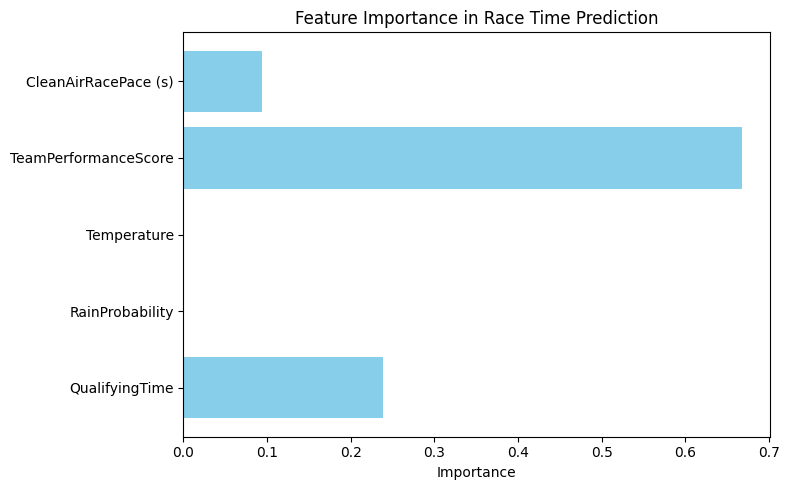

In [130]:
# Plot feature importances
feature_importance = model.feature_importances_
features = X.columns 

plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Race Time Prediction")
plt.tight_layout()
plt.show()